<a href="https://colab.research.google.com/github/404himel/CNN/blob/main/riceClassificationUsingCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/

cp: cannot stat '/content/kaggle.json': No such file or directory


In [2]:
#!/bin/bash
!kaggle datasets download muratkokludataset/rice-image-dataset

Dataset URL: https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset
License(s): CC0-1.0
 92% 201M/219M [00:02<00:00, 109MB/s]
100% 219M/219M [00:02<00:00, 100MB/s]


In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/rice-image-dataset.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
dataset = '/content/Rice_Image_Dataset'

In [5]:
import os
for fol in os.listdir(dataset):
  print(fol)

Basmati
Karacadag
Rice_Citation_Request.txt
Ipsala
Jasmine
Arborio


In [7]:
import shutil

# Path to the dataset
dataset_path = "/content/Rice_Image_Dataset/.ipynb_checkpoints"

# Remove the .ipynb_checkpoints folder
shutil.rmtree(dataset_path)
print(f"Removed: {dataset_path}")


Removed: /content/Rice_Image_Dataset/.ipynb_checkpoints


In [14]:
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Input
from tensorflow.keras.models import Sequential

In [10]:
datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)


In [12]:
train = datagen.flow_from_directory(
    dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
validation = datagen.flow_from_directory(
    dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
print(train.class_indices)

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.
{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}


In [13]:
# Get a single batch of images and labels
images, labels = next(train)


print("Batch shape (images):", images.shape)
print("Batch shape (labels):", labels.shape)


Batch shape (images): (32, 224, 224, 3)
Batch shape (labels): (32, 5)


In [17]:
#model
input = (224,224,3)
model = Sequential()
model.add(Input(input))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(5,activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,908,037 (91.20 MB)

 Trainable params: 23,908,037 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [21]:
history = model.fit(train,validation_data=validation,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9814 - loss: 0.0534

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 133s 70ms/step - accuracy: 0.9814 - loss: 0.0534 - val_accuracy: 0.9933 - val_loss: 0.0216
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 116s 56ms/step - accuracy: 0.9896 - loss: 0.0307 - val_accuracy: 0.9940 - val_loss: 0.0186
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 57ms/step - accuracy: 0.9916 - loss: 0.0243 - val_accuracy: 0.9887 - val_loss: 0.0363
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 121s 64ms/step - accuracy: 0.9938 - loss: 0.0177 - val_accuracy: 0.9941 - val_loss: 0.0192
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 108s 57ms/step - accuracy: 0.9955 - loss: 0.0126 - val_accuracy: 0.9929 - val_loss: 0.0235


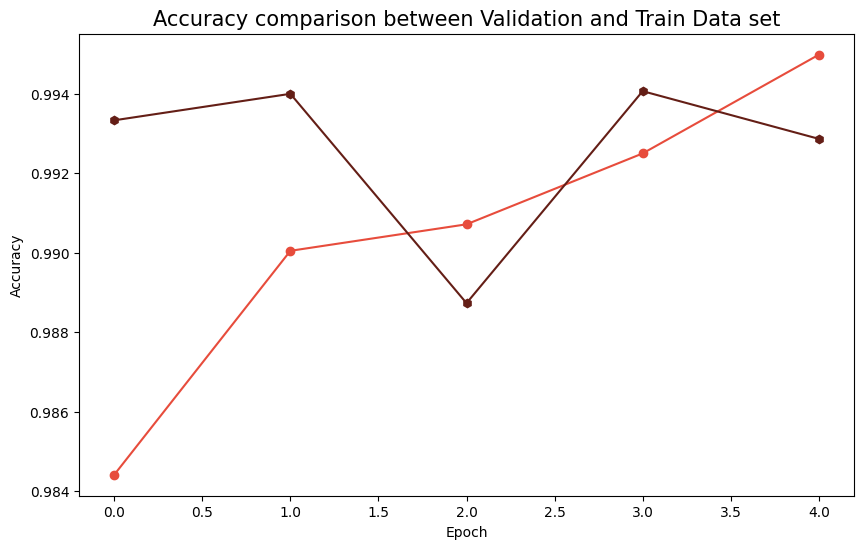

In [24]:
#Accuracy comparison between Validation and Train Data set
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# Access the training metrics using history.history
plt.plot(history.history['accuracy'],color="#E74C3C",marker='o')
plt.plot(history.history['val_accuracy'],color='#641E16',marker='h')
plt.title('Accuracy comparison between Validation and Train Data set',fontsize=15)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.show()

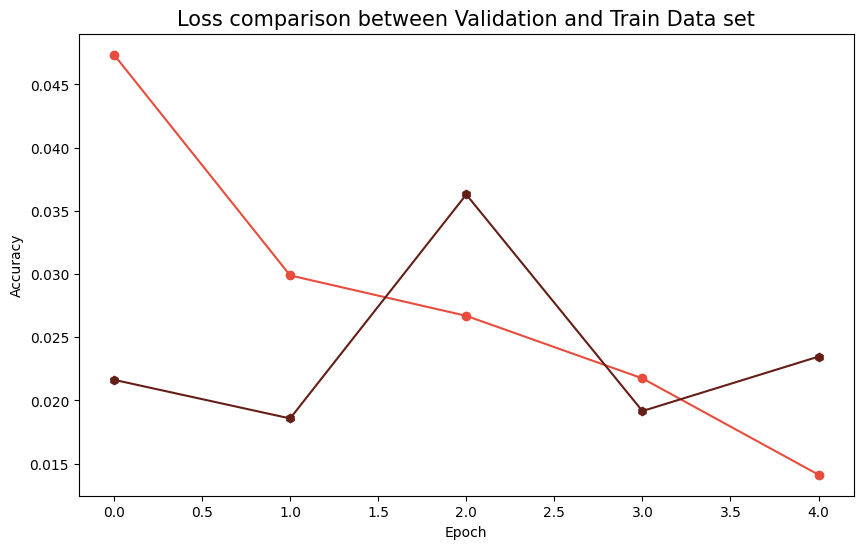

In [25]:
#Loss comparison between Validation and Train Data set
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'],color="#E74C3C",marker='o')
plt.plot(history.history['val_loss'],color='#641E16',marker='h')
plt.title('Loss comparison between Validation and Train Data set',fontsize=15)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.show()

In [26]:
# Evaluate the model on the test data
metrics = model.evaluate(validation)
# Print the accuracy of the model
print('Accuracy:', metrics[1])

469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9934 - loss: 0.0249
Accuracy: 0.9928666949272156


In [31]:
classes = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

In [33]:
import cv2
import numpy as np
img = cv2.imread('/content/download (2).jpeg')
img = cv2.resize(img,(224,224))
img = img.reshape(1,224,224,3)
prediction = model.predict(img)
class_index = np.argmax(prediction)
class_name = classes[class_index]
print("Predicted Class is: ",class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted Class is:  Ipsala


In [36]:
import cv2
import numpy as np
img = cv2.imread('/content/download (3).jpeg')
img = cv2.resize(img,(224,224))
img = img.reshape(1,224,224,3)
prediction = model.predict(img)
class_index = np.argmax(prediction)
class_name = classes[class_index]
print("Predicted Class is: ",class_name)
conf = np.max(prediction)
print(f"Confidence score: {conf:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Class is:  Ipsala
Confidence score: 1.00


In [34]:
# Save the model
model.save('CNN_model.h5')
print ("Model saved successfully!")

Model saved successfully!
